# Computer Vision with FPGAs

* Image data consists of height x width x depth, for example 32x32x3 with 8bit values per channel for regular RGB images.
* Previous examples process the full input in one clock cycle and processes all of it in parallel
* Images require a different method since no FPGA is able to process a full image at once
* hls4ml has another processing strategy: `io_stream` which implements a pipeline that consumes single pixel at a time
* Architecture known as shift-register, processes data continuously on the fly by shifting pixels through registers
* **Line buffer**:  A hardware queue that delays incoming pixels by exactly one image row's width, vertically adjacent pixels arrive at the same time to form a 2D window.
* **Shift buffer**:  A temporary vertical column that catches the brand new incoming pixel alongside the older pixels popping out of the line buffers, stacking them to be pushed into the kernel window all at once
* **Kernel window**:  A 2D array of hardware registers that holds the currently aligned patch of image pixels, shifting left to accept new data from the shift buffer every clock cycle to perform the actual matrix multiplication with the weights

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

input_stream = ['P0,0', 'P0,1', 'P0,2', 'P1,0', 'P1,1', 'P1,2', 'P2,0', 'P2,1', 'P2,2']
line_buffer_data = ['0', '0', '0'] 
kernel_window_data = [['0', '0'], ['0', '0']]
shift_buffer_data = ['0', '0']
total_steps = len(input_stream) + 1

valid_multiplication_map = {
    4: (0, 0),
    5: (0, 1),
    7: (1, 0),
    8: (1, 1)
}

fig, axs = plt.subplots(1, 6, figsize=(18, 3.5))
fig.suptitle('FPGA Shift-Register Pipeline: 3x3 Input -> 2x2 Output', fontsize=14, y=1.05)

input_rects = []
for r in range(3):
    for c in range(3):
        rect = plt.Rectangle((c, 2 - r), 1, 1, facecolor='#f9f9f9', edgecolor='gray')
        axs[0].add_patch(rect)
        axs[0].text(c + 0.5, 2.5 - r, f'P{r},{c}', ha='center', va='center', fontsize=9)
        input_rects.append(rect)
axs[0].set_xlim(0, 3)
axs[0].set_ylim(0, 3)
axs[0].set_title('Input Stream')
axs[0].axis('off')

lb_rects = []
for i in range(3):
    rect = plt.Rectangle((i, 0), 1, 1, facecolor='#e0e0e0', edgecolor='black')
    axs[1].add_patch(rect)
    text = axs[1].text(i + 0.5, 0.5, '0', ha='center', va='center', fontsize=10)
    lb_rects.append(text)
axs[1].set_xlim(0, 3)
axs[1].set_ylim(0, 1)
axs[1].set_title('Line Buffer (Len 3)')
axs[1].axis('off')

sb_texts = []
for i in range(2):
    rect = plt.Rectangle((0, 1 - i), 1, 1, facecolor='#d0e8f2', edgecolor='black')
    axs[2].add_patch(rect)
    text = axs[2].text(0.5, 1.5 - i, '0', ha='center', va='center', fontsize=10)
    sb_texts.append(text)
axs[2].set_xlim(0, 1)
axs[2].set_ylim(0, 2)
axs[2].set_title('Shift Buffer')
axs[2].axis('off')

kw_texts = []
for r in range(2):
    row_texts = []
    for c in range(2):
        rect = plt.Rectangle((c, 1 - r), 1, 1, facecolor='#f2d0d0', edgecolor='black')
        axs[3].add_patch(rect)
        text = axs[3].text(c + 0.5, 1.5 - r, '0', ha='center', va='center', fontsize=11, fontweight='bold')
        row_texts.append(text)
    kw_texts.append(row_texts)
axs[3].set_xlim(0, 2)
axs[3].set_ylim(0, 2)
axs[3].set_title('Kernel Window')
axs[3].axis('off')

out_rects = []
out_texts = []
for r in range(2):
    row_rects = []
    row_texts = []
    for c in range(2):
        rect = plt.Rectangle((c, 1 - r), 1, 1, facecolor='#eeeeee', edgecolor='black')
        axs[4].add_patch(rect)
        text = axs[4].text(c + 0.5, 1.5 - r, '?', ha='center', va='center', fontsize=11, color='gray')
        row_rects.append(rect)
        row_texts.append(text)
    out_rects.append(row_rects)
    out_texts.append(row_texts)
axs[4].set_xlim(0, 2)
axs[4].set_ylim(0, 2)
axs[4].set_title('Output Data')
axs[4].axis('off')

status_text = axs[5].text(0.5, 0.5, 'Initializing...', ha='center', va='center', fontsize=11, color='gray')
axs[5].set_title('Compute Status')
axs[5].axis('off')

plt.tight_layout()

def update(frame):
    global line_buffer_data, kernel_window_data, shift_buffer_data
    
    if frame == 0:
        return

    pixel_idx = frame - 1
    current_pixel = input_stream[pixel_idx]

    for i, rect in enumerate(input_rects):
        if i == pixel_idx:
            rect.set_facecolor('#a0d0ff') 
        elif i < pixel_idx:
            rect.set_facecolor('#d3d3d3') 

    pushed_out = line_buffer_data.pop(0)
    line_buffer_data.append(current_pixel)

    shift_buffer_data[0] = pushed_out
    shift_buffer_data[1] = current_pixel

    kernel_window_data[0][0] = kernel_window_data[0][1]
    kernel_window_data[1][0] = kernel_window_data[1][1]
    kernel_window_data[0][1] = shift_buffer_data[0]
    kernel_window_data[1][1] = shift_buffer_data[1]

    for i in range(3): lb_rects[i].set_text(line_buffer_data[i])
    for i in range(2): sb_texts[i].set_text(shift_buffer_data[i])
    for r in range(2):
        for c in range(2): kw_texts[r][c].set_text(kernel_window_data[r][c])

    if pixel_idx in valid_multiplication_map:
        out_r, out_c = valid_multiplication_map[pixel_idx]
        
        out_rects[out_r][out_c].set_facecolor('#8cf08c')
        out_texts[out_r][out_c].set_text(f'Out\n{out_r},{out_c}')
        out_texts[out_r][out_c].set_color('black')
        out_texts[out_r][out_c].set_fontweight('bold')
        
        status_text.set_text("VALID WINDOW\nWriting Output!")
        status_text.set_color('green')
        status_text.set_fontweight('bold')
        
    elif pixel_idx % 3 == 0 and pixel_idx != 0:
        status_text.set_text("Edge wrap...\nSkipping Mul")
        status_text.set_color('orange')
        status_text.set_fontweight('normal')
        
    else:
        status_text.set_text("Window incomplete\nSkipping Mul")
        status_text.set_color('red')
        status_text.set_fontweight('normal')

ani = animation.FuncAnimation(fig, update, frames=total_steps, interval=1600, repeat=False)
plt.close()

HTML(ani.to_jshtml())

## Remove release version for a version with bugfix

In [4]:
!pip uninstall hls4ml -y


Found existing installation: hls4ml 1.3.0
Uninstalling hls4ml-1.3.0:
  Successfully uninstalled hls4ml-1.3.0


In [5]:
!pip install git+https://github.com/laurilaatu/hls4ml.git@oneapi_weights -y

  Cloning https://github.com/laurilaatu/hls4ml.git (to revision oneapi_weights) to /tmp/pip-req-build-v3rq_7vz
  Running command git clone --filter=blob:none --quiet https://github.com/laurilaatu/hls4ml.git /tmp/pip-req-build-v3rq_7vz
  Running command git checkout -b oneapi_weights --track origin/oneapi_weights
  Switched to a new branch 'oneapi_weights'
  branch 'oneapi_weights' set up to track 'origin/oneapi_weights'.
  Resolved https://github.com/laurilaatu/hls4ml.git to commit a17fae7143473b51a0be43bb67c462ca49e8a689
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hls4ml: filename=hls4ml-0.6.0.dev571+ga17fae71-py3-none-any.whl size=3301205 sha256=a5e121757fa9f4fd94eb70f0c96572c152673dbaa392a25d02fa77403eb4b8c1
  Stored in directory: /tmp/pip-ephem-wheel-cache-645s29gz/wheels/46/f1/1e/6c4ebb9b2f61440916c83594d3332d3e

In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"
#CUDA available?
#os.environ['JAX_PLATFORMS'] = 'cuda'

from glob import glob
import keras
from keras import layers
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import random
from keras import layers
from keras.layers import Conv2D, MaxPooling2D, Dense

In [8]:
print(f"Using Keras backend: {keras.backend.backend()}")

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(x_train.shape, y_train.shape)

Using Keras backend: jax
(50000, 32, 32, 3) (50000, 1)


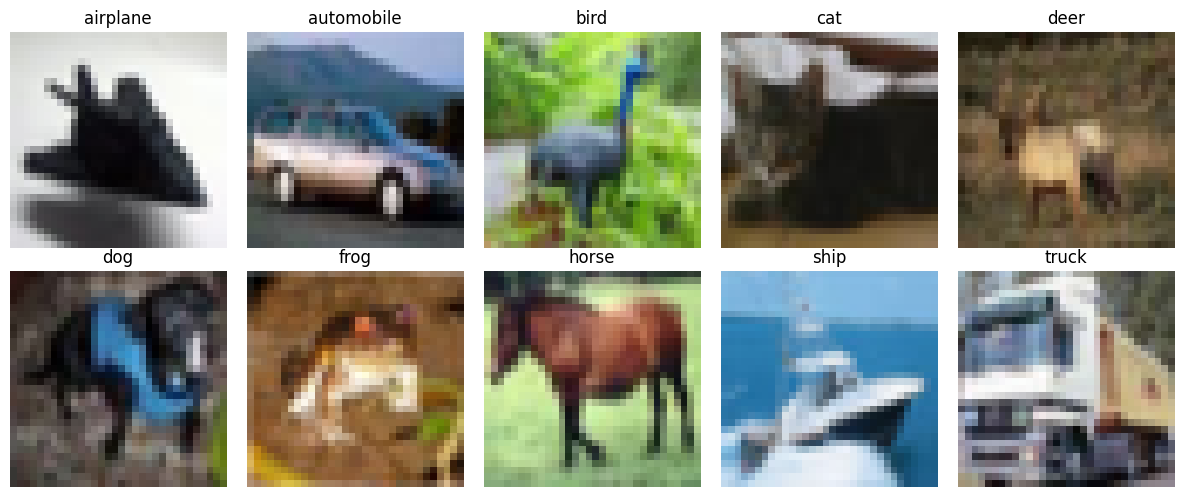

In [12]:


class_names = [
    "airplane", "automobile", "bird", "cat", "deer", 
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(12, 5))

for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    
    img = x_train[idx]
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
def get_standard_vgg():
    # CIFAR-10 shape: 32x32x3
    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(4, kernel_size=3, strides=1, padding="same", use_bias=True, activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)
    
    x = layers.Conv2D(8, kernel_size=3, strides=1, padding="same", use_bias=True, activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    
    x = layers.Conv2D(16, kernel_size=3, strides=1, padding="same", use_bias=True, activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    
    x = layers.Conv2D(32, kernel_size=3, strides=1, padding="same", use_bias=True, activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    

    outputs = layers.Dense(10, activation='softmax')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="standard_nano_vgg")

In [11]:


model = get_standard_vgg()
model.summary()

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=5,
    validation_split=0.1,
)



Model: "standard_nano_vgg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 4)      │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,730 (45.82 KB)

 Trainable params: 11,730 (45.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3174 - loss: 1.8732 - val_accuracy: 0.4024 - val_loss: 1.6561
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4416 - loss: 1.5581 - val_accuracy: 0.4394 - val_loss: 1.5262
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4786 - loss: 1.4495 - val_accuracy: 0.4950 - val_loss: 1.4075
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5029 - loss: 1.3838 - val_accuracy: 0.4888 - val_loss: 1.4164
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5217 - loss: 1.3395 - val_accuracy: 0.5218 - val_loss: 1.3222


# HGQ Training

### Quantization and pruning with gradient-based method

In [13]:
# HGQ Imports
import hgq
from hgq.config import LayerConfigScope, QuantizerConfigScope
from hgq.layers import QDense, QAdd, QConv2D, QBatchNormalization, QGlobalAveragePooling2D, QMaxPooling2D
from hgq.utils.sugar import FreeEBOPs, BetaScheduler
from hgq.regularizers import MonoL1

from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from keras.callbacks import ReduceLROnPlateau, TerminateOnNaN

In [14]:
def get_q_vgg(beta0=1e-10):
    # HGQ Configuration Scopes
    scope0 = QuantizerConfigScope(k0=1, b0=6, i0=2, br=MonoL1(1e-10), overflow_mode='WRAP',
        bc=hgq.constraints.MinMax(0, 8))
    scope1 = QuantizerConfigScope(place='datalane', heterogeneous_axis=(), k0=1, f0=6, fr=MonoL1(1e-10), ir=MonoL1(1e-10),
        bc=hgq.constraints.MinMax(0, 8))
    betascope = LayerConfigScope(beta0=beta0)

    with betascope, scope0, scope1:
        # CIFAR-10 shape: 32x32x3
        inputs = keras.Input(shape=(32, 32, 3))

        # Initial Layer
        x = QConv2D(4, kernel_size=3, strides=2, padding="same", use_bias=True, activation='relu')(inputs)
        x = QMaxPooling2D(pool_size=2)(x)
        x = QConv2D(8, kernel_size=3, strides=1, padding="same", use_bias=True, activation='relu')(x)
        x = QMaxPooling2D(pool_size=2)(x)
        x = QConv2D(16, kernel_size=3, strides=1, padding="same", use_bias=True, activation='relu')(x)
        x = QMaxPooling2D(pool_size=2)(x)
        x = QConv2D(32, kernel_size=3, strides=1, padding="same", use_bias=True, activation='relu')(x)
        x = QMaxPooling2D(pool_size=2)(x)
        
        x = layers.Flatten()(x)
        x = QDense(32, activation="relu")(x)
        x = QDense(32, activation="relu")(x)
        outputs = QDense(10)(x)


    return keras.Model(inputs=inputs, outputs=outputs, name="hgq_nano_vgg")

In [15]:
model_save_prefix = "hgq_nano_vgg"


Using Keras backend: jax


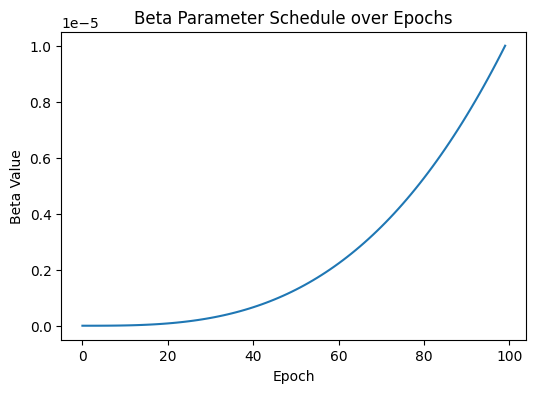

Model: "hgq_nano_vgg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_conv2d_8 (QConv2D)            │ (None, 16, 16, 4)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_max_pooling2d_8               │ (None, 8, 8, 4)        │             6 │
│ (QMaxPooling2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_conv2d_9 (QConv2D)            │ (None, 8, 8, 8)        │         1,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_max_pooling2d_9               │ (None, 4, 4, 8)        │             6 │
│ (QMaxPooling2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_conv2d_10 (QConv2D)           │ (None, 4, 4, 16)       │         4,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_max_pooling2d_10              │ (None, 2, 2, 16)       │             6 │
│ (QMaxPooling2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_conv2d_11 (QConv2D)           │ (None, 2, 2, 32)       │        18,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_max_pooling2d_11              │ (None, 1, 1, 32)       │             6 │
│ (QMaxPooling2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_dense_6 (QDense)              │ (None, 32)             │         4,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_dense_7 (QDense)              │ (None, 32)             │         4,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_dense_8 (QDense)              │ (None, 10)             │         1,328 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,712 (110.20 KB)

 Trainable params: 17,327 (67.68 KB)

 Non-trainable params: 17,385 (42.51 KB)

Epoch 1/100
784/782 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1878 - loss: 2.1223
Epoch 1: saving model to hgq_nano_vgg_001.keras

Epoch 1: finished saving model to hgq_nano_vgg_001.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.2587 - loss: 1.9544 - val_accuracy: 0.3696 - val_loss: 1.7009 - ebops: 2944180.0000 - beta: 1.0000e-15
Epoch 2/100
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3681 - loss: 1.6915
Epoch 2: saving model to hgq_nano_vgg_002.keras

Epoch 2: finished saving model to hgq_nano_vgg_002.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3821 - loss: 1.6655 - val_accuracy: 0.4082 - val_loss: 1.6141 - ebops: 2944180.0000 - beta: 1.0307e-11
Epoch 3/100
784/782 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4045 - loss: 1.6091
Epoch 3: saving model to hgq_nano_vgg_003.keras

Epoch 3: finished saving model to hgq_nano_vgg_003.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4106 - loss: 1.5972 - val_accuracy: 0.4273 

In [30]:

# 1. Load and Preprocess Data (Pure NumPy)
print(f"Using Keras backend: {keras.backend.backend()}")



q_epochs = 100 # You might want to lower this for initial testing
# aporox 10sec per epoch on laptop
# starting beta
beta0 = 1e-15
#end beta
beta1 = 1e-5

sched = lambda x: beta1 * np.linspace(0, 1, q_epochs)[x]**3 + beta0
beta_sched = BetaScheduler(sched)

plt.figure(figsize=(6, 4))
plt.plot([sched(i) for i in range(q_epochs)])
plt.title("Beta Parameter Schedule over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Beta Value")
plt.show()

ebops_tracker = FreeEBOPs()
nan_terminate = keras.callbacks.TerminateOnNaN()


checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=model_save_prefix+"_{epoch:03d}.keras",
    monitor='val_accuracy',
    save_best_only=False,
    save_weights_only=False,
    verbose=1
)

callbacks = [ebops_tracker, nan_terminate, beta_sched, checkpoint_cb]


model = get_q_vgg(beta0=beta0)

loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=loss,
    metrics=["accuracy"],
    jit_compile=True, 
    steps_per_execution=4
)

model.summary()

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    batch_size=64,
    epochs=q_epochs,
    callbacks=callbacks,
    verbose=1
)



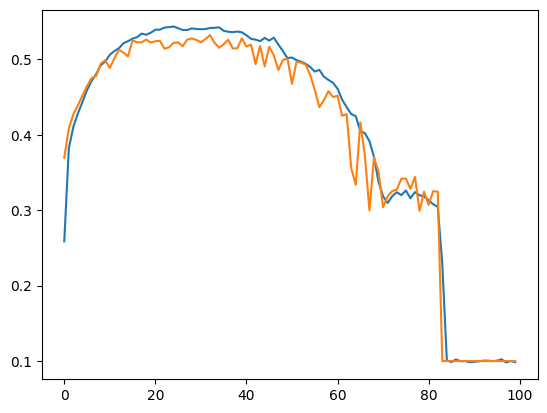

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


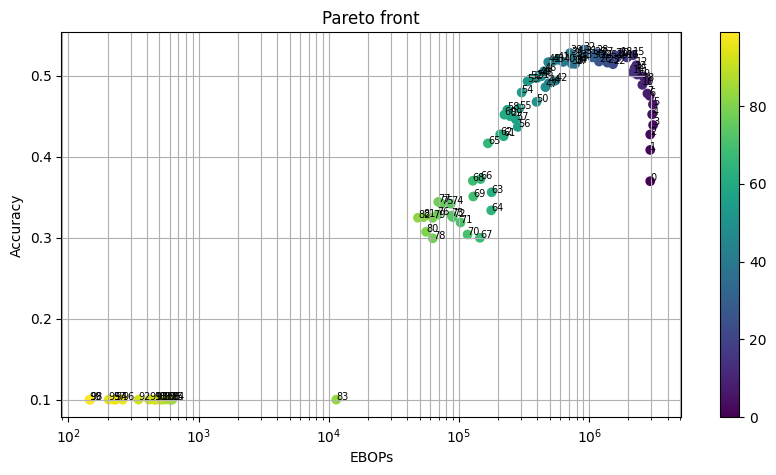

In [32]:
plt.figure(figsize=(10,5))
plt.scatter(history.history['ebops'], history.history['val_accuracy'], c=np.arange(len(history.history['val_accuracy'])))
for i in range(len(history.history['val_accuracy'])):
    plt.text(history.history['ebops'][i], history.history['val_accuracy'][i],i ,fontsize=7)
plt.xscale("log")
plt.grid("both", "both")

plt.title("Pareto front")
plt.xlabel("EBOPs")
plt.ylabel("Accuracy")
#plt.xlim(10e4, 10e9)
plt.colorbar()

hgq_nano_vgg_001.keras
'InputLayer' object has no attribute 'kq'
q_conv2d_12 1941344
q_max_pooling2d_12 10240
'QMaxPooling2D' object has no attribute 'kq'
q_conv2d_13 1243136
q_max_pooling2d_13 5120
'QMaxPooling2D' object has no attribute 'kq'
q_conv2d_14 1026048
q_max_pooling2d_14 2816
'QMaxPooling2D' object has no attribute 'kq'
q_conv2d_15 721920
q_max_pooling2d_15 1280
'QMaxPooling2D' object has no attribute 'kq'
'Flatten' object has no attribute 'kq'
q_dense_9 82176
q_dense_10 90368
q_dense_11 28240
hgq_nano_vgg_030.keras
'InputLayer' object has no attribute 'kq'
q_conv2d_12 604147
q_max_pooling2d_12 9216
'QMaxPooling2D' object has no attribute 'kq'
q_conv2d_13 441838
q_max_pooling2d_13 5632
'QMaxPooling2D' object has no attribute 'kq'
q_conv2d_14 469262
q_max_pooling2d_14 2816
'QMaxPooling2D' object has no attribute 'kq'
q_conv2d_15 261803
q_max_pooling2d_15 1408
'QMaxPooling2D' object has no attribute 'kq'
'Flatten' object has no attribute 'kq'
q_dense_9 35726
q_dense_10 33946
q

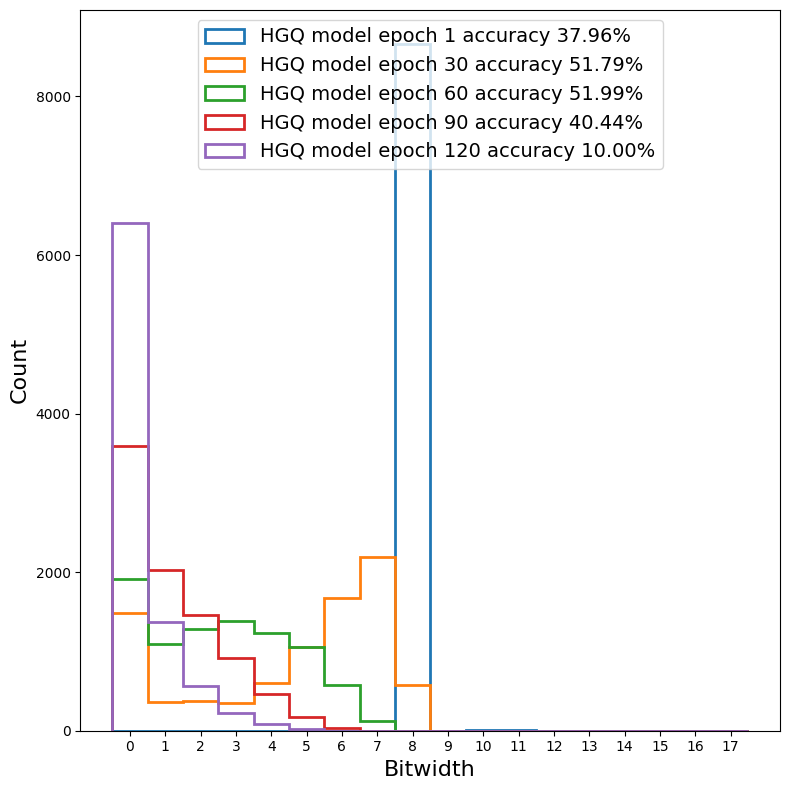

In [21]:

from glob import glob

plt.figure(figsize=(8,8))

jump = 30

for idx, i in enumerate(sorted(glob(f"{model_save_prefix}_*.keras"))[:1]+sorted(glob(f"{model_save_prefix}_*.keras"))[jump-1:4*jump+1:jump]):
    
    print(i)
    plt_model = keras.saving.load_model(i)
    
    bitwidths = []
    for l in plt_model.layers:
        if hasattr(l, "ebops"):
            print(l.name, l.ebops)
        if "attention" not in l.name:
            #print(l.name)
            try:
                bitwidths += list(l.kq.bits.flatten())
                bitwidths += list(l.iq.bits.flatten())
                bitwidths += list(l.bq.bits.flatten())
            except Exception as e:
                print(e)
    
    
    plt.hist(bitwidths, histtype="step", linewidth=2,
             range=(-0.5, 17.5), bins=18 ,
             label=f"HGQ model epoch {idx*jump if idx != 0 else 1} accuracy {100* history.history['val_accuracy'][idx*jump]:.2f}%")
    
#plt.grid(True, which="both", linestyle=':')
plt.xlabel('Bitwidth', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.tight_layout()
plt.xticks(np.arange(0,18,1), np.arange(0,18,1))
#plt.yscale("log")
plt.legend(fontsize=14, loc='upper center')

plt.show()


### hls4ml conversion

In [ ]:
print("we saved the model for all epochs")
glob(f"{model_save_prefix}_*.keras")

In [37]:
import hls4ml
from hgq.utils import trace_minmax, dataset

def patched_make_html_table_template(table_header, row_templates):
    """Hotfix for broken table creation"""
    num_columns = len(next(iter(row_templates.values())))

    _row_html_template = '        <tr><td>{}</td>' + ''.join('<td>{{{}}}</td>' for _ in range(num_columns)) + '</tr>'

    table_rows = '\n'.join(
        [_row_html_template.format(row_title, *row_keys) for row_title, row_keys in row_templates.items()]
    )
    return hls4ml.report.oneapi_report._table_base_template.format(
        colspan=num_columns + 1, 
        table_header=table_header, 
        table_rows=table_rows
    )

epoch = 80

#gpu available?
#test_data = dataset.Dataset(x_test, device="gpu:0", batch_size=1024)
test_data = dataset.Dataset(x_test, device="cpu:0", batch_size=1024)


synth_model = keras.saving.load_model(sorted(glob(f"{model_save_prefix}_*.keras"))[epoch])


print("Hardware Resource Analysis (EBOPs)")
ebops_sum = 0
for layer in synth_model.layers:
    if hasattr(layer, 'ebops'):
        print(f"{layer.name}: {layer.ebops}")
        ebops_sum += layer.ebops

print(f"Total Estimated EBOPs before minmax: {ebops_sum}")

# trace runs through the test set and searches for over/underflows
# Might yield a model that is incompatible with oneAPI fixed datatypes...
#trace_minmax(synth_model, test_data, verbose=True)





Hardware Resource Analysis (EBOPs)
q_conv2d_8: 4768
q_max_pooling2d_8: 5120
q_conv2d_9: 8944
q_max_pooling2d_9: 2560
q_conv2d_10: 8975
q_max_pooling2d_10: 1792
q_conv2d_11: 10416
q_max_pooling2d_11: 896
q_dense_6: 4990
q_dense_7: 4035
q_dense_8: 3359
Total Estimated EBOPs before minmax: 55855


## hls4ml with io_stream

In [49]:
dir_name = f"hls4ml_cnn_io_stream_test"


# Bitwidths are extracted automatically from the HGQ model (2 bits acts as a placeholder)

hls_config = {
    'Model': {
        'Precision': 'ac_fixed<2,0>',
        'ReuseFactor': 1
    }
}

model_hls = hls4ml.converters.convert_from_keras_model(
    synth_model,
    output_dir=dir_name,
    io_type='io_stream',
    backend='oneAPI',
    part='Agilex7',
    hls_config=hls_config,
    clock_period='2'
)


In [ ]:

#model_hls.write()
#model_hls.build()
model_hls.build(build_type='report')

# Try report creation and compare with io_parallel

In [41]:


dir_name = f"hls4ml_cnn_io_parallel"


# Bitwidths are extracted automatically from the HGQ model (2 bits acts as a placeholder)

hls_config = {
    'Model': {
        'Precision': 'ac_fixed<2,0>',
        'ReuseFactor': 1
    }
}

model_hls = hls4ml.converters.convert_from_keras_model(
    synth_model,
    output_dir=dir_name,
    io_type='io_parallel',
    backend='oneAPI',
    part='Agilex7',
    hls_config=hls_config,
    clock_period='2'
)


In [ ]:

#model_hls.write()
#model_hls.build()
model_hls.build(build_type='report')

In [ ]:
hls4ml.report.oneapi_report._make_html_table_template = patched_make_html_table_template

report = hls4ml.report.oneapi_report.parse_oneapi_report(dir_name)


hls4ml.report.oneapi_report.print_oneapi_report(report)

Error: unable to fully generate static reports for this compile!